In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import json
import os

# ==========================================
# 1. CONFIGURATION (Local Mac Paths)
# ==========================================

# We use relative paths now. '.' means "current folder"
BASE_DIR = './dataset' 
DATA_DIR = os.path.join(BASE_DIR, 'animals')
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'validation')

IMG_SIZE = (224, 224) 
BATCH_SIZE = 32

print(f"TensorFlow Version: {tf.__version__}")
print(f"Looking for data in: {os.path.abspath(DATA_DIR)}")

# ==========================================
# 2. DATA AUGMENTATION & LOADING
# ==========================================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

print("\n--- Loading Training Data ---")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("\n--- Loading Validation Data ---")
validation_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# ==========================================
# 3. GENERATE JSON METADATA
# ==========================================

# keys must match folder names exactly
scientific_lookup = {
    'lion': 'Panthera leo',
    'tiger': 'Panthera tigris',
    'elephant': 'Loxodonta',
    'zebra': 'Equus quagga',
    'eagle': 'Aquila chrysaetos'
    # Add your specific animals here
}

class_indices = train_generator.class_indices
index_to_label = {v: k for k, v in class_indices.items()}
species_metadata = []

for i in range(len(index_to_label)):
    common_name = index_to_label[i]
    scientific_name = scientific_lookup.get(common_name, "Unknown Classification")
    
    species_metadata.append({
        "id": i,
        "common_name": common_name.capitalize(),
        "scientific_name": scientific_name,
        "description": f"Identified as {common_name} ({scientific_name})."
    })

# Save JSON to the dataset folder
json_path = os.path.join(BASE_DIR, 'species_data.json')
with open(json_path, 'w') as f:
    json.dump(species_metadata, f, indent=4)

print(f"\n✅ Metadata saved locally at: {json_path}")

# ==========================================
# 4. BUILD MODEL (MobileNetV2)
# ==========================================

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 5. TRAIN
# ==========================================

print("\n--- Starting Training ---")
EPOCHS = 10 # Start small to test your Mac's speed

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

# ==========================================
# 6. EXPORT TO TFLITE
# ==========================================

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = os.path.join(BASE_DIR, 'creature_archive_model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print("\nSUCCESS!")
print(f"Model saved to: {tflite_path}")

TensorFlow Version: 2.20.0
Looking for data in: /Users/lemkyahamed/Downloads/CreatureProject/dataset/animals

--- Loading Training Data ---
Found 65883 images belonging to 101 classes.

--- Loading Validation Data ---
Found 65883 images belonging to 101 classes.

✅ Metadata saved locally at: ./dataset/species_data.json
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step

--- Starting Training ---
Epoch 1/10
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 1070s 519ms/step - accuracy: 0.5469 - loss: 2.0688 - val_accuracy: 0.7951 - val_loss: 0.9664
Epoch 2/10
   1/2058 ━━━━━━━━━━━━━━━━━━━━ 9:03 264ms/step - accuracy: 0.7188 - loss: 1.2156

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2058/2058 ━━━━━━━━━━━━━━━━━━━━ 523s 254ms/step - accuracy: 0.7188 - loss: 1.2156 - val_accuracy: 0.7949 - val_loss: 0.9661
Epoch 3/10
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 1065s 518ms/step - accuracy: 0.7576 - loss: 1.0033 - val_accuracy: 0.8350 - val_loss: 0.6974
Epoch 4/10
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 505s 245ms/step - accuracy: 0.8438 - loss: 0.6667 - val_accuracy: 0.8349 - val_loss: 0.6972
Epoch 5/10
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 1075s 522ms/step - accuracy: 0.7888 - loss: 0.8348 - val_accuracy: 0.8506 - val_loss: 0.6057
Epoch 6/10
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 504s 245ms/step - accuracy: 0.8438 - loss: 1.0823 - val_accuracy: 0.8507 - val_loss: 0.6057
Epoch 7/10
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 1227s 597ms/step - accuracy: 0.8052 - loss: 0.7561 - val_accuracy: 0.8602 - val_loss: 0.5599
Epoch 8/10
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 498s 242ms/step - accuracy: 0.9062 - loss: 0.7563 - val_accuracy: 0.8604 - val_loss: 0.5600
Epoch 9/10
2058/2058 ━━━━━━━━━━━━━━━━━━━━ 1064s 517ms/step - accuracy:

INFO:tensorflow:Assets written to: /var/folders/wm/sj4htk096317qwyzxhgxhmwc0000gn/T/tmpo_rkn3tc/assets


Saved artifact at '/var/folders/wm/sj4htk096317qwyzxhgxhmwc0000gn/T/tmpo_rkn3tc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 101), dtype=tf.float32, name=None)
Captures:
  5264408208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5264407440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5264406480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5264408400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5264408016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5264407056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5286445328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5286445520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5264407248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5264407824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5286445904: Tensor

W0000 00:00:1769607685.489555 5422856 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1769607685.489578 5422856 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-01-28 19:11:25.490972: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wm/sj4htk096317qwyzxhgxhmwc0000gn/T/tmpo_rkn3tc
2026-01-28 19:11:25.495777: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-01-28 19:11:25.495785: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/wm/sj4htk096317qwyzxhgxhmwc0000gn/T/tmpo_rkn3tc
I0000 00:00:1769607685.540088 5422856 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-01-28 19:11:25.549325: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-01-28 19:11:25.867144: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folder

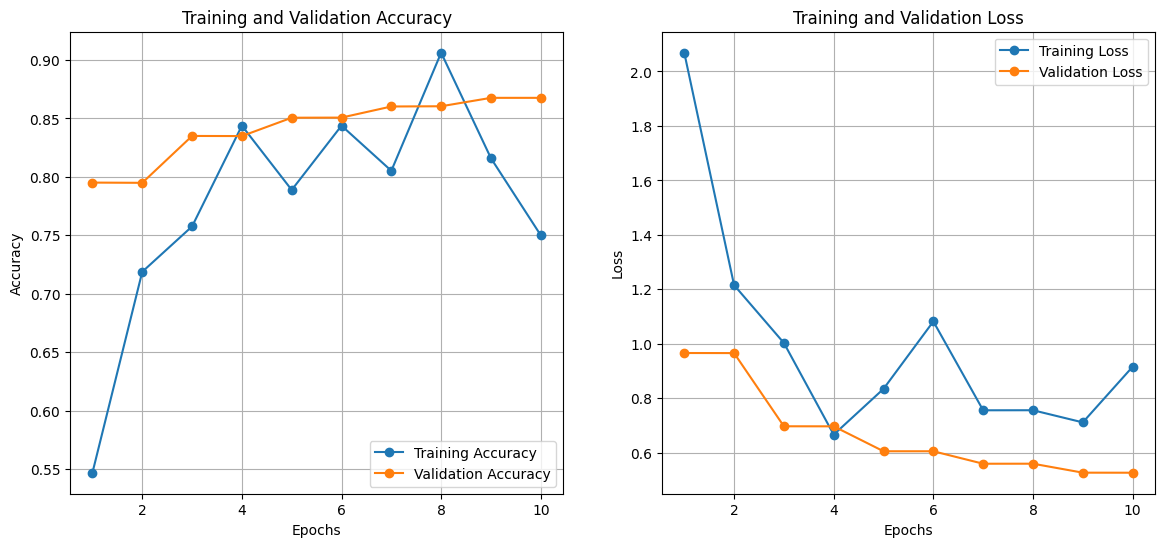

In [2]:
import matplotlib.pyplot as plt

# ==========================================
# RECONSTRUCT HISTORY FROM LOGS
# ==========================================

# I manually typed these from your log data above:
epochs_range = range(1, 11)

# Training Data
acc = [0.5469, 0.7188, 0.7576, 0.8438, 0.7888, 0.8438, 0.8052, 0.9062, 0.8159, 0.7500]
loss = [2.0688, 1.2156, 1.0033, 0.6667, 0.8348, 1.0823, 0.7561, 0.7563, 0.7117, 0.9159]

# Validation Data
val_acc = [0.7951, 0.7949, 0.8350, 0.8349, 0.8506, 0.8507, 0.8602, 0.8604, 0.8676, 0.8676]
val_loss = [0.9664, 0.9661, 0.6974, 0.6972, 0.6057, 0.6057, 0.5599, 0.5600, 0.5271, 0.5269]

# ==========================================
# PLOT THE CURVES
# ==========================================

plt.figure(figsize=(14, 6))

# --- Plot Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)

# --- Plot Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.show()